<a href="https://colab.research.google.com/github/Subroy1/MSAI_AllPracticeModules/blob/main/Module%2010/ARIMA_SARIMA_Assignment10_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Required Assignment 10.4: Time Series and Sales

**Expected Time = 60 minutes**

**Total Points = 50**

This activity is meant to extend your work with ARMA models to apply a forecasting model across stores in a retail chain, and items in each store.  You will build models for each store for a specific item and compare this forecast to the model, aggregating all stores.  Also, you will compare a model for sales by store for all items and discuss expected performance for each store according to your forecast.  

In addition to the ARMA models, you will explore an extension of this to include seasonality elements with the SARIMA model.  Both are implemented with `statsmodels`.   

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)
- [Problem 4](#-Problem-4)
- [Problem 5](#-Problem-5)
- [Problem 6](#-Problem-6)

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from warnings import filterwarnings
filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import mean_squared_error

### The Data

The data is from a past time series competition on Kaggle [here](https://www.kaggle.com/c/demand-forecasting-kernels-only).  It represents historical sales across 10 stores of 50 items.  Each observation is a day's total sales by store and item.  

In [ ]:
df= pd.read_csv("data/train.csv.zip", compression='zip')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [ ]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


[Back to top](#-Index)

### Problem 1

#### Structuring the data and time series

**5 Points**

To begin, notice that the DataFrame `df` does not have a datetime index.  Below, convert the `date` column to a datetime object and set it as the index to a new DataFrame called `stores_df` below.

In [ ]:
### GRADED
stores_df = ''
# YOUR CODE HERE
stores_df=df.copy()
stores_df['date']=pd.to_datetime(df['date'])
stores_df.set_index('date', inplace=True)

# Answer check
stores_df.head()
print('------------\nData Info\n')
print(stores_df.info())


------------
Data Info

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB
None


In [ ]:
stores_df.head(2)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11


[Back to top](#-Index)

### Problem 2

#### Store 1 Model

**10 Points**

In anticipation of building a 30-day forecast for sales of item 1 in store 1, subset the data to only the sales column for item 1 store 1 and assign as a DataFrame to `store_1_item_1` below.

In [ ]:
### GRADED
store_1_item_1 = ''
# YOUR CODE HERE
#store_1_item_1= pd.DataFrame(stores_df[stores_df['store']==1 ]['sales'])
store_1_item_1 = stores_df[ (stores_df['store']==1)  &  (stores_df['item']==1)]['sales']
store_1_item_1= pd.DataFrame(store_1_item_1)

# Answer check
print(store_1_item_1.head())
print(store_1_item_1.shape)

            sales
date             
2013-01-01     13
2013-01-02     11
2013-01-03     14
2013-01-04     13
2013-01-05     10
(1826, 1)


[Back to top](#-Index)

### Problem 3

#### Train/Test split

**5 Points**

Now, use the store 1 data from the previous question to create a train-test split where `train_data` is all but the last 30 days of sales data.  You no longer need the store and item columns.  Assign these values as `X_train` and `X_test` respectively.

In [ ]:
### GRADED
X_train, X_test = '', ''
# YOUR CODE HERE
size=len(store_1_item_1)
X_test=store_1_item_1[-30:]
X_train=store_1_item_1[:(size-30)]

# Answer check
print(X_train.tail())
print(X_test.head())


            sales
date             
2017-11-27     10
2017-11-28     14
2017-11-29     28
2017-11-30     15
2017-12-01     19
            sales
date             
2017-12-02     16
2017-12-03     31
2017-12-04      7
2017-12-05     20
2017-12-06     17


[Back to top](#-Index)

### Problem 4

#### Assumptions of Linearity

**10 Points**

Next, you will want to check the assumptions of our model before building it.  Specifically, this was the notion that our time series is stationary for the ARMA models.  Use the `adfuller` function to determine if the series is stationary.  Assign the $p$ value to `pval` below.  Consider your threshold at $p = 0.01$.  

In [ ]:
pd.DataFrame(stores_df[stores_df['store'] ==1]['sales']).shape

(91300, 1)

In [ ]:
### GRADED
pval = ''
# YOUR CODE HERE
fullerval=adfuller(pd.DataFrame(X_train))
pval=fullerval[1]

# Answer check
print(f'The p-value is {pval: .4f}')
fullerval # The p-value is  0.0266 hence the series is non stationary .

The p-value is  0.0266


(-3.099625939498419,
 0.02658088302259768,
 23,
 1772,
 {'1%': -3.4340457100503534,
  '5%': -2.8631724504188356,
  '10%': -2.5676390661481077},
 10709.450865297767)

[Back to top](#-Index)

### Problem 5

#### Autocorrelation and Partial Autocorrelation

**10 Points**

Backing up the results of our hypothesis test, the autocorrelation of the original series seems to not be stationary.  Instead, the differenced data and its ACF and PACF plots look better.  We will begin by using these plots to suggest an `order = (1, 0, 1)` model based on the differenced data.  Accordingly, build an `ARIMA` model with `order = (1, 0, 1)` and fit on the training data and assign to `arma` below.

Determine the mean squared error on the test data and assign it as a float to `mse_test` below.  


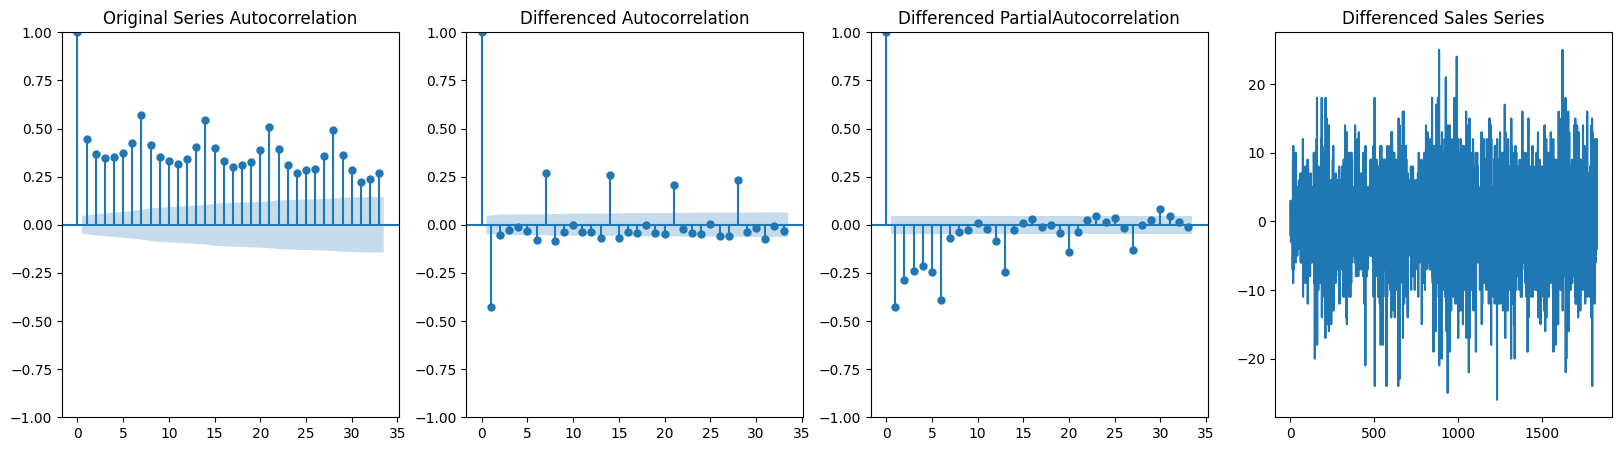

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))
plot_acf(df[(df['store'] == 1) & (df['item'] == 1)]['sales'], ax = ax[0]);
ax[0].set_title('Original Series Autocorrelation')

plot_acf(df[(df['store'] == 1) & (df['item'] == 1)]['sales'].diff().dropna(), ax = ax[1]);
ax[1].set_title('Differenced Autocorrelation')

plot_pacf(df[(df['store'] == 1) & (df['item'] == 1)]['sales'].diff().dropna(), ax = ax[2], method = 'ywm');
ax[2].set_title('Differenced PartialAutocorrelation')

ax[3].plot(df[(df['store'] == 1) & (df['item'] == 1)]['sales'].diff().dropna())
ax[3].set_title('Differenced Sales Series');

# Looking at the differenced PACF and ACF plots , it is an AR and MA model of order 1 . AR(1) and MA(1)

In [ ]:
### GRADED
# YOUR CODE HERE
#The model learns the dynamics of the differenced series
X_train_diff=X_train.diff()
arma = ARIMA(X_train_diff,order = (1, 0, 1)).fit()

#X_test_diff=X_test.diff().dropna()
preds=  arma.forecast(steps=len(X_test))
mse_test= mean_squared_error(X_test,preds)

### ANSWER CHECK
print(preds[:5])
print(mse_test)

2017-12-02    2.767694
2017-12-03    0.216277
2017-12-04    0.022110
2017-12-05    0.007334
2017-12-06    0.006209
Freq: D, Name: predicted_mean, dtype: float64
320.39147462124214


In [ ]:
### BEGIN HIDDEN TESTS
arma_ = ARIMA(X_train.diff(), order = (1, 0, 1), freq = 'D').fit()
preds_ = arma_.forecast(len(X_test))
mse_test_ = mean_squared_error(preds_, X_test)
#
#
#
assert mse_test == mse_test_

print(mse_test, mse_test_)
### END HIDDEN TESTS

320.39147462124214 320.39147462124214


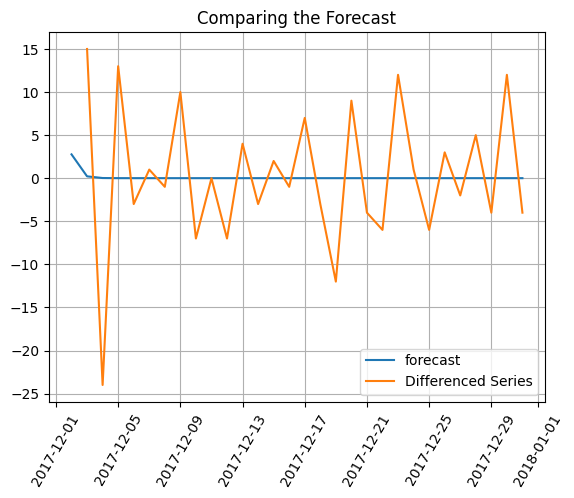

In [ ]:
plt.plot(arma.forecast(steps = len(X_test)), label = 'forecast')
plt.plot(X_test.diff(), label = 'Differenced Series')
plt.title('Comparing the Forecast')
plt.legend();
plt.xticks(rotation = 60)
plt.grid();

[Back to top](#-Index)

### Problem 6

#### A Model with Seasonality

**10 Points**

As discussed with the decomposition models earlier, there are ways to consider a seasonal oscillation within the data.  For ARIMA, a version that adds in a seasonal element is called SARIMA.  In statsmodels, we use the `SARIMAX` estimator to build this model that includes seasonal elements.

Much like the decomposition model, you can have a multiplicative or additive seasonality.  For a multiplicative seasonal effect that we determine is yearly we add an argument

```
seasonal_order=(1, 1, 0, 12)
```

along with the `order = (1, 0, 1)`.  For more information see the user guide from statsmodels [here](https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_sarimax_stata.html).

Below, build a `SARIMAX` estimator with the above order and seasonality and fit on the training data.  Assign the fit model to `sarima` below.

In [ ]:
stores_df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
X_train, X_test = stores_df['sales'].iloc[-700:-30], stores_df.iloc[-30:]

In [ ]:
X_test.head(2)

,date,store,item,sales
912970,2017-12-02,10,50,49
912971,2017-12-03,10,50,75


In [ ]:
### GRADED
#NOTE: in your fit statement, use .fit(disp=0)
# YOUR CODE HERE
#seasonal_order=(1, 1, 0, 12) along with the order = (1, 0, 1)
sarima = SARIMAX( X_train,  order= (1,0,1), seasonal_order= (1,1,0,12), simple_differencing=True).fit(disp=0)#simple_differencing=True,

### ANSWER CHECK
sarima.summary()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                          DS12.sales   No. Observations:                 1784
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood               -5941.424
Date:                             Fri, 13 Feb 2026   AIC                          11890.847
Time:                                     13:20:07   BIC                          11912.794
Sample:                                 01-13-2013   HQIC                         11898.952
                                      - 12-01-2017                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0439      0.132     -0.333      0.739      -0.303       0.215
ma.L1          0.2193      0.130      1.687      0.092      -0.035       0.474
ar.S.L12      -0.4587      0.021    -21.806      0.000      -0.500      -0.417
sigma2        45.6636      1.428     31.970      0.000      42.864      48.463
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                10.13
Prob(Q):                              0.97   Prob(JB):                         0.01
Heteroskedasticity (H):               1.44   Skew:                             0.10
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.31
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

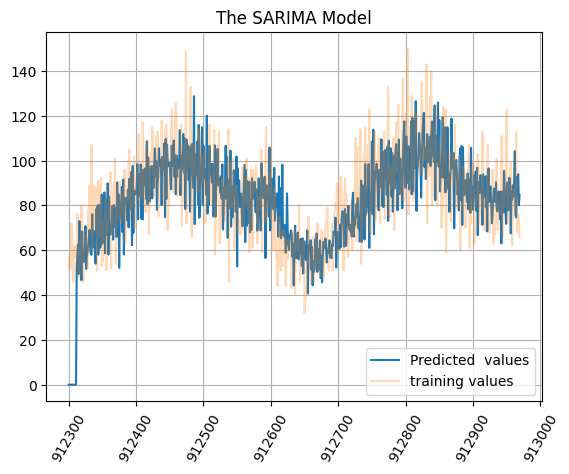

In [ ]:
plt.plot(X_train.index, sarima.predict(), label='Predicted  values')
plt.plot(X_train.index, X_train, alpha = 0.3, label='training values')
plt.xticks(rotation = 60)
plt.title('The SARIMA Model')
plt.grid();
plt.legend()

As you see, the SARIMA model can pick up the seasonal trends we have in this dataset.  You can also get a more sensitive ARMA model by using higher-order terms.  If you are interested in further work here, try grid-searching order and seasonality hyperparameters to determine the best model and order/seasonality parameters.

Also, you can incorporate other features about the data as exogenous elements of both the ARMA and SARIMA models in statsmodels.  Consider trying engineering features with `ts_fresh` and using an exogenous model to see if this improves performance.